In [354]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from pathlib import Path
import registration_utils as ru
import cv2
import pandas as pd

from capillary_roi import (
    select_and_track_capillary,
    extract_af488_curve
)

In [337]:
nd2_path = Path("project/data/170619_Rat2glom001.nd2")
(
    data,
    registration_stack,
    transforms,
    drift_df
) = ru.analyse_nd2_drift(
    nd2_path,
    registration_channel=1
)

In [338]:
print("Dimensions:", data.dims)
print("Shape:", data.shape)
print("Channels:", data.coords["C"].values)

Dimensions: ('T', 'C', 'Y', 'X')
Shape: (49, 3, 1024, 1024)
Channels: ['FITC' 'Rhodamine Phalloidin' 'TD']


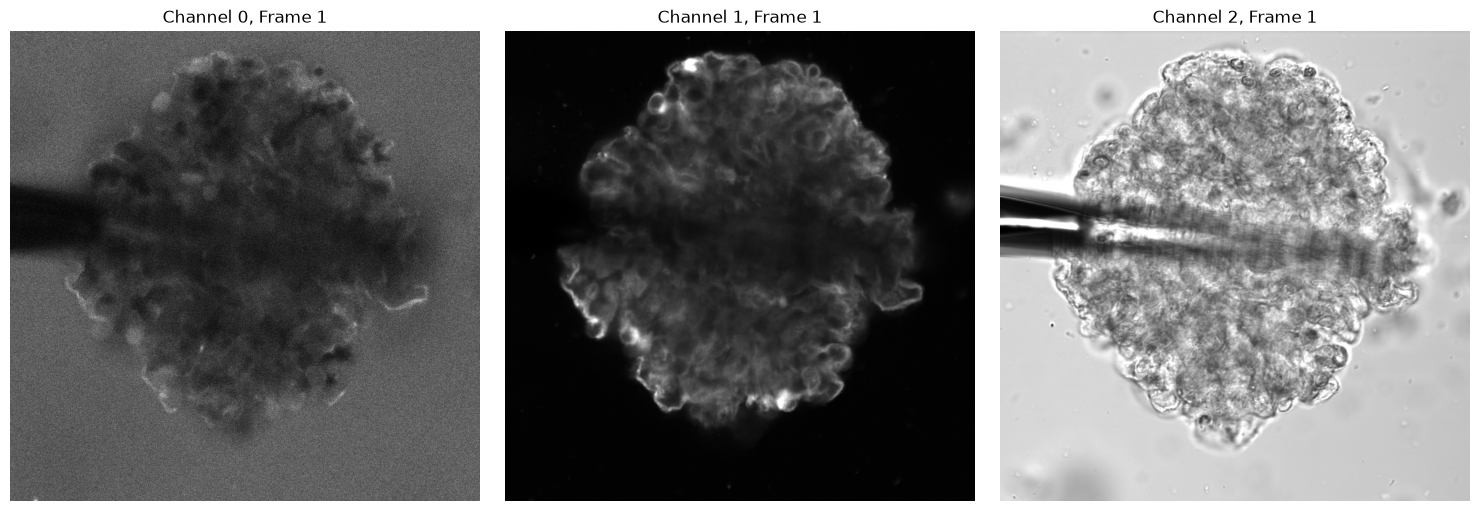

In [339]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)

for c in range(3):

    axes[c].imshow(
        data.isel(T=0, C=c).compute().values,
        cmap="gray"
    )

    axes[c].set_title(
        f"Channel {c}, Frame 1"
    )

    axes[c].axis("off")

plt.tight_layout()
plt.show()

In [340]:
af488 = (
    data
    .isel(C=0)
    .compute()
    .values
)

r18 = (
    data
    .isel(C=1)
    .compute()
    .values
)

print("AF488 shape:", af488.shape)
print("R18 shape:", r18.shape)

AF488 shape: (49, 1024, 1024)
R18 shape: (49, 1024, 1024)


In [341]:
r18_registered = ru.register_stack(
    r18,
    transforms
)

af488_registered = ru.register_stack(
    af488,
    transforms
)

print(
    "R18 registered:",
    r18_registered.shape
)

print(
    "AF488 registered:",
    af488_registered.shape
)

R18 registered: (49, 1024, 1024)
AF488 registered: (49, 1024, 1024)


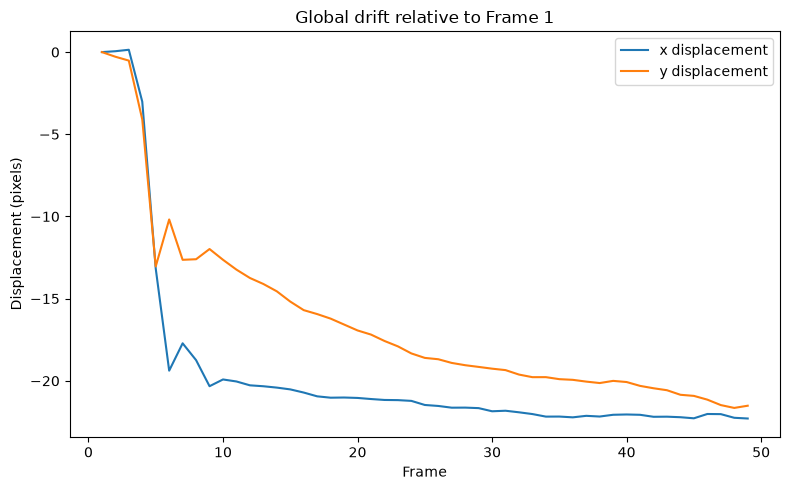

In [342]:
plt.figure(figsize=(8, 5))

plt.plot(
    drift_df["frame"],
    drift_df["x"],
    label="x displacement"
)

plt.plot(
    drift_df["frame"],
    drift_df["y"],
    label="y displacement"
)

plt.xlabel("Frame")
plt.ylabel("Displacement (pixels)")
plt.title("Global drift relative to Frame 1")

plt.legend()
plt.tight_layout()
plt.show()

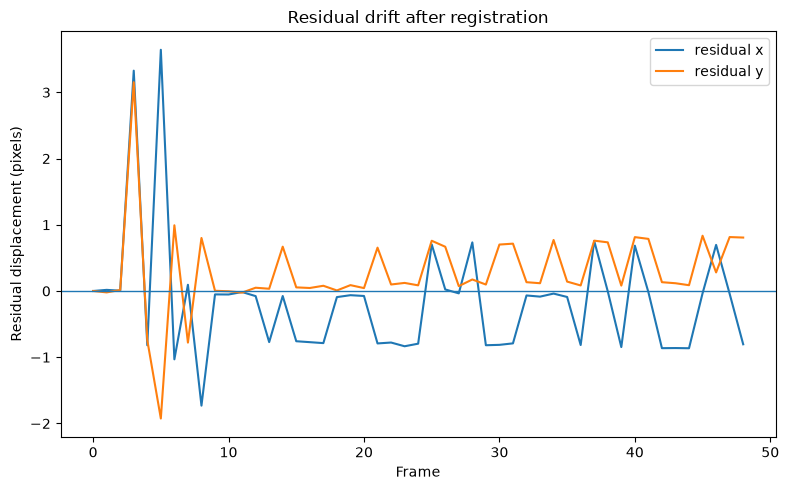

Maximum residual drift: 4.5835 pixels


In [355]:
reference_registered = r18_registered[0].astype(np.float32)

residual_x = []
residual_y = []

for frame in r18_registered:
    current_frame = frame.astype(np.float32)

    # Estimate translation relative to the first registered frame
    shift, response = cv2.phaseCorrelate(
        reference_registered,
        current_frame
    )

    # cv2.phaseCorrelate returns (x, y)
    residual_x.append(shift[0])
    residual_y.append(shift[1])

residual_df = pd.DataFrame({
    "frame": np.arange(len(r18_registered)),
    "residual_x": residual_x,
    "residual_y": residual_y
})

# Plot residual drift
plt.figure(figsize=(8, 5))

plt.plot(
    residual_df["frame"],
    residual_df["residual_x"],
    label="residual x"
)

plt.plot(
    residual_df["frame"],
    residual_df["residual_y"],
    label="residual y"
)

plt.axhline(0, linewidth=1)

plt.xlabel("Frame")
plt.ylabel("Residual displacement (pixels)")
plt.title("Residual drift after registration")

plt.legend()
plt.tight_layout()
plt.show()

# Calculate maximum residual drift magnitude
residual_magnitude = np.sqrt(
    residual_df["residual_x"]**2 +
    residual_df["residual_y"]**2
)

max_residual_drift = residual_magnitude.max()

print(
    f"Maximum residual drift: "
    f"{max_residual_drift:.4f} pixels"
)

In [343]:
def to_uint8(image):
    image = np.asarray(image)

    image_min = np.min(image)
    image_max = np.max(image)

    if image_max == image_min:
        return np.zeros_like(image, dtype=np.uint8)

    image_norm = (
        (image - image_min)
        / (image_max - image_min)
    )

    return (
        image_norm * 255
    ).astype(np.uint8)

In [344]:
import importlib
import capillary_roi

importlib.reload(capillary_roi)

from capillary_roi import (
    select_and_track_capillary,
    extract_af488_curve
)

print("capillary_roi reloaded")

capillary_roi reloaded


Left-click once on the centre of the capillary loop.
Selected centre: 722 704


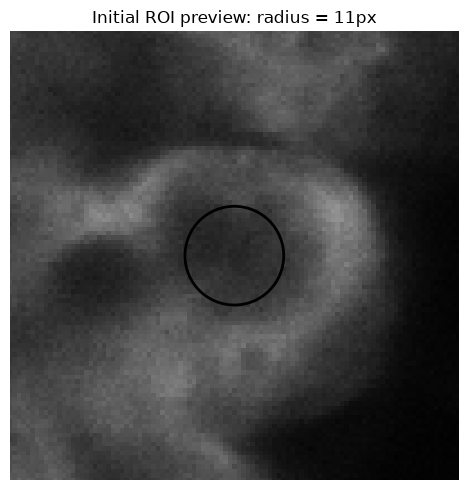

Enter measurement ROI radius [default 11]:  9


Confirmed measurement ROI radius: 9
Tracking radius: 12


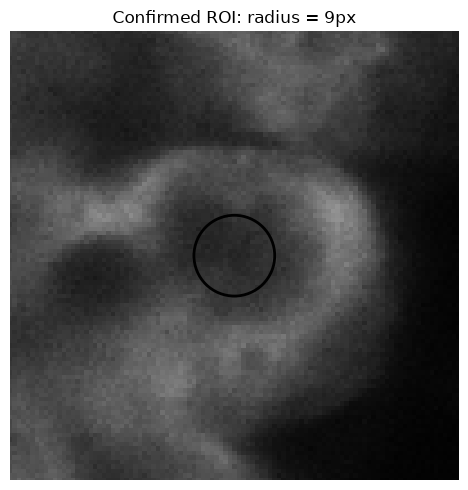

Tracking success: 49 / 49


In [372]:
(
    selected_centre,
    roi_radius,
    tracked_centres,
    
    tracking_success,
    tracked_boxes
) = select_and_track_capillary(
    registered_stack=r18_registered,
    to_uint8_func=to_uint8,
    tracking_radius=12,
    default_radius=11
)

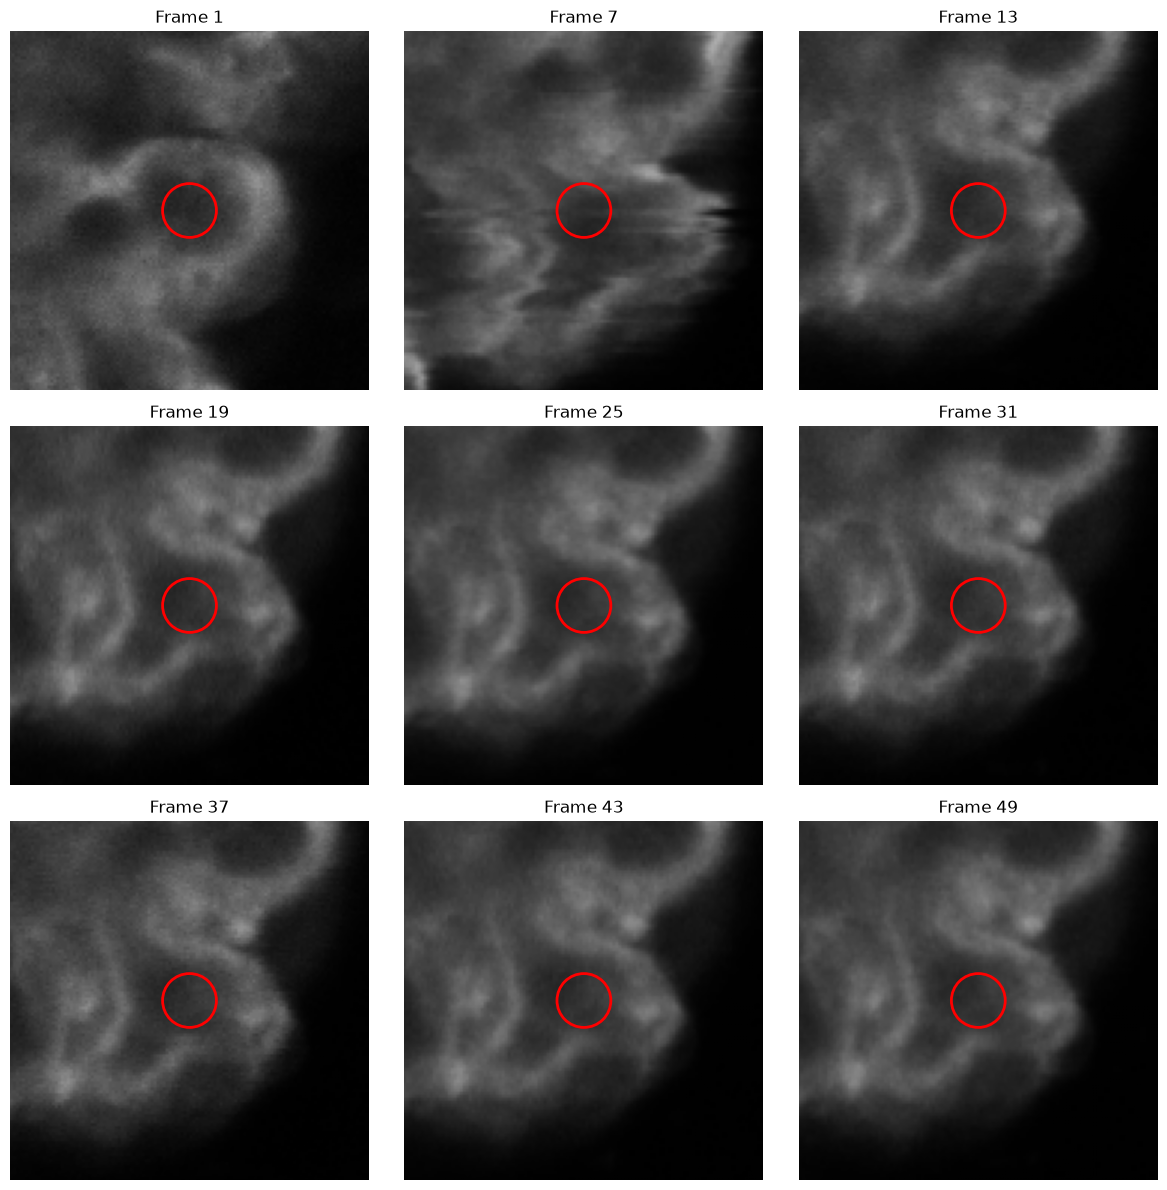

In [373]:
from matplotlib.patches import Circle

check_frames = np.linspace(
    0,
    len(r18_registered) - 1,
    9,
    dtype=int
)

fig, axes = plt.subplots(
    3,
    3,
    figsize=(12, 12)
)

for ax, frame_index in zip(
    axes.ravel(),
    check_frames
):
    ax.imshow(
        r18_registered[frame_index],
        cmap="gray"
    )

    centre_x_t, centre_y_t = tracked_centres[
        frame_index
    ]

    if (
        np.isfinite(centre_x_t)
        and np.isfinite(centre_y_t)
    ):
        circle = Circle(
            (centre_x_t, centre_y_t),
            roi_radius,
            fill=False,
            edgecolor="red",
            linewidth=2
        )

        ax.add_patch(circle)

        ax.set_xlim(
            centre_x_t - 60,
            centre_x_t + 60
        )

        ax.set_ylim(
            centre_y_t + 60,
            centre_y_t - 60
        )

    ax.set_title(
        f"Frame {frame_index + 1}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

In [374]:
def run_tracking_test(
    registered_stack,
    centre_x,
    centre_y,
    tracking_radius,
    to_uint8_func
):
    """
    Run CSRT tracking for one tracking radius.
    """

    bbox = (
        int(centre_x - tracking_radius),
        int(centre_y - tracking_radius),
        int(2 * tracking_radius),
        int(2 * tracking_radius)
    )

    tracker = cv2.TrackerCSRT_create()

    first_frame = cv2.cvtColor(
        to_uint8_func(
            registered_stack[0]
        ),
        cv2.COLOR_GRAY2BGR
    )

    tracker.init(
        first_frame,
        bbox
    )

    tracked_boxes = [bbox]
    tracking_success = [True]

    for i in range(
        1,
        len(registered_stack)
    ):

        frame = cv2.cvtColor(
            to_uint8_func(
                registered_stack[i]
            ),
            cv2.COLOR_GRAY2BGR
        )

        ok, box = tracker.update(
            frame
        )

        tracking_success.append(
            bool(ok)
        )

        if ok:
            tracked_boxes.append(
                box
            )
        else:
            tracked_boxes.append(
                (
                    np.nan,
                    np.nan,
                    np.nan,
                    np.nan
                )
            )

    tracked_centres = []

    for box in tracked_boxes:

        x, y, w, h = box

        if np.isfinite(x):

            tracked_centres.append(
                (
                    x + w / 2,
                    y + h / 2
                )
            )

        else:

            tracked_centres.append(
                (
                    np.nan,
                    np.nan
                )
            )

    tracked_centres = np.asarray(
        tracked_centres,
        dtype=float
    )

    tracking_success = np.asarray(
        tracking_success,
        dtype=bool
    )

    return (
        tracked_centres,
        tracking_success
    )

In [375]:
centre_x, centre_y = selected_centre

print("Centre x:", centre_x)
print("Centre y:", centre_y)

Centre x: 722
Centre y: 704


In [376]:
tracking_radii = [
    12,
    14,
    16,
    18
]

tracking_results = {}

for tr in tracking_radii:

    centres_test, success_test = (
        run_tracking_test(
            registered_stack=r18_registered,
            centre_x=centre_x,
            centre_y=centre_y,
            tracking_radius=tr,
            to_uint8_func=to_uint8
        )
    )

    tracking_results[tr] = {
        "centres": centres_test,
        "success": success_test
    }

    print(
        f"Tracking radius {tr}: "
        f"{success_test.sum()} / "
        f"{len(success_test)}"
    )

Tracking radius 12: 49 / 49
Tracking radius 14: 49 / 49
Tracking radius 16: 49 / 49
Tracking radius 18: 49 / 49


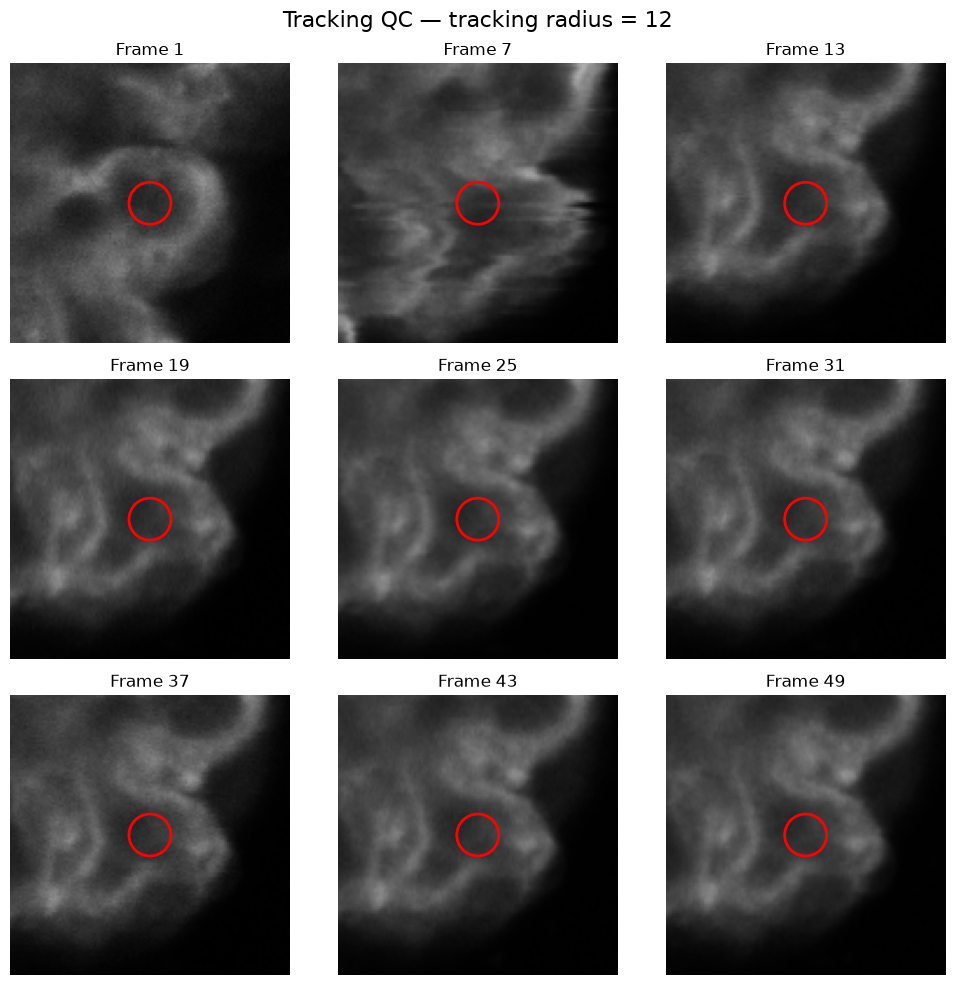

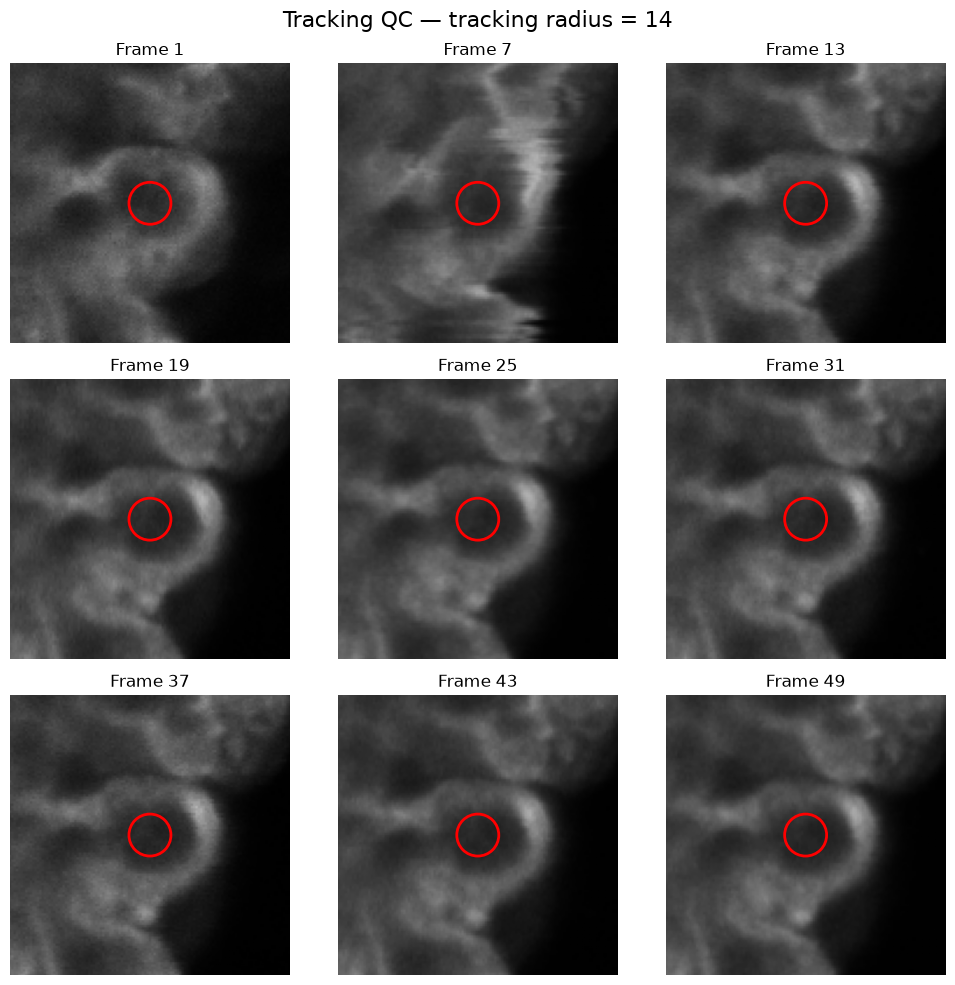

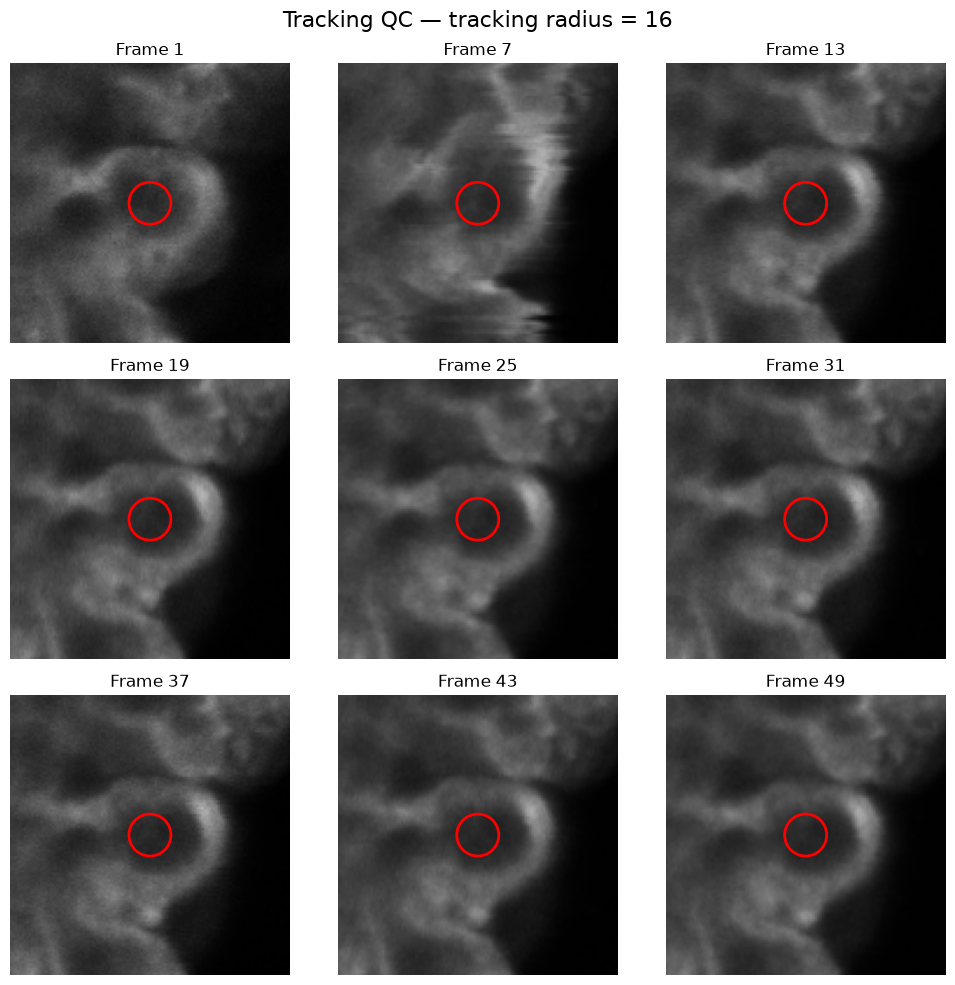

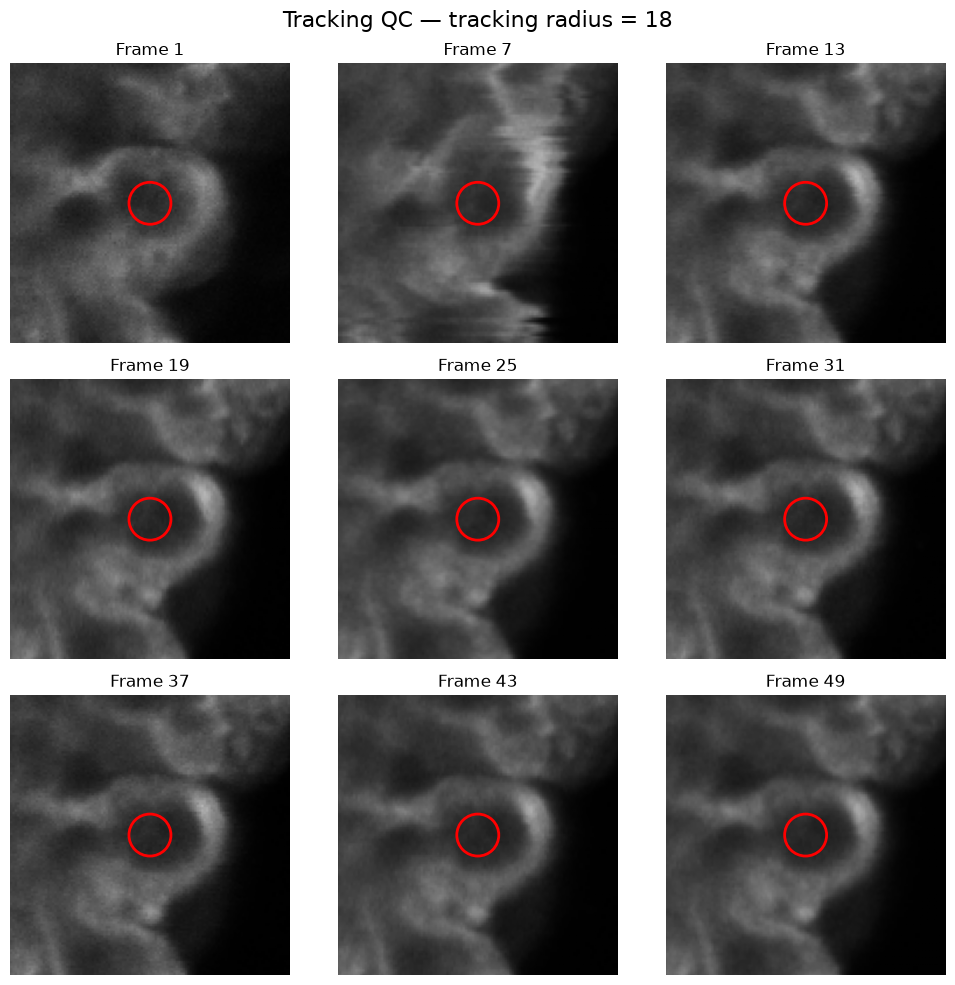

In [377]:
check_frames = np.linspace(
    0,
    len(r18_registered) - 1,
    9,
    dtype=int
)

for tr in tracking_radii:

    centres_test = (
        tracking_results[tr]["centres"]
    )

    fig, axes = plt.subplots(
        3,
        3,
        figsize=(10, 10)
    )

    for ax, frame_index in zip(
        axes.ravel(),
        check_frames
    ):

        ax.imshow(
            r18_registered[frame_index],
            cmap="gray"
        )

        centre_x_t, centre_y_t = (
            centres_test[frame_index]
        )

        if (
            np.isfinite(centre_x_t)
            and
            np.isfinite(centre_y_t)
        ):

            circle = Circle(
                (
                    centre_x_t,
                    centre_y_t
                ),
                roi_radius,          # measurement ROI
                fill=False,
                edgecolor="red",
                linewidth=2
            )

            ax.add_patch(
                circle
            )

            ax.set_xlim(
                centre_x_t - 60,
                centre_x_t + 60
            )

            ax.set_ylim(
                centre_y_t + 60,
                centre_y_t - 60
            )

        ax.set_title(
            f"Frame {frame_index + 1}"
        )

        ax.axis(
            "off"
        )

    fig.suptitle(
        f"Tracking QC — tracking radius = {tr}",
        fontsize=16
    )

    plt.tight_layout()
    plt.show()

In [419]:
available_radii = [12, 14, 16, 18]

while True:
    try:
        tracking_radius = int(
            input(
                f"Select tracking radius {available_radii}: "
            )
        )

        if tracking_radius in available_radii:
            break
        else:
            print(
                f"Please select one of: {available_radii}"
            )

    except ValueError:
        print("Please enter a valid number.")

# Load tracking results for the selected radius
tracked_centres = tracking_results[tracking_radius]["centres"]
tracking_success = tracking_results[tracking_radius]["success"]

print(
    "\nFinal tracking radius:",
    tracking_radius
)

print(
    "Tracking success:",
    tracking_success.sum(),
    "/",
    len(tracking_success)
)

Select tracking radius [12, 14, 16, 18]:  18



Final tracking radius: 18
Tracking success: 49 / 49


In [379]:
time_seconds, af488_intensity = extract_af488_curve(
    af488_registered=af488_registered,
    tracked_centres=tracked_centres,
    roi_radius=roi_radius,
    frame_interval=4.0
)

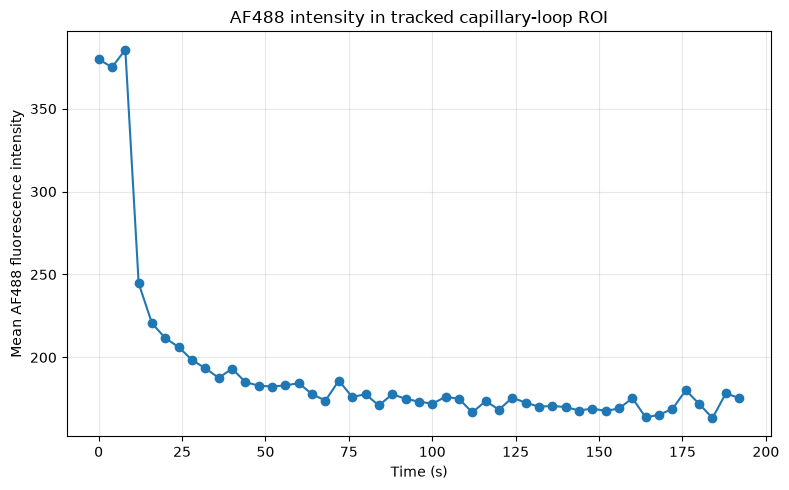

In [380]:
plt.figure(figsize=(8, 5))

plt.plot(
    time_seconds,
    af488_intensity,
    marker="o"
)

plt.xlabel("Time (s)")
plt.ylabel("Mean AF488 fluorescence intensity")

plt.title(
    "AF488 intensity in tracked capillary-loop ROI"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [410]:
wash_end_time = float(
    input("Enter wash-end time (s): ")
)

analysis_duration = 60.0

analysis_mask = (
    (time_seconds >= wash_end_time)
    &
    (time_seconds <= wash_end_time + analysis_duration)
)

analysis_time = time_seconds[analysis_mask]
analysis_intensity = af488_intensity[analysis_mask]

print("Wash-end time:", wash_end_time, "s")
print(
    "Analysis window:",
    wash_end_time,
    "to",
    wash_end_time + analysis_duration,
    "s"
)
print("Frames included:", len(analysis_time))

Enter wash-end time (s):  40


Wash-end time: 40.0 s
Analysis window: 40.0 to 100.0 s
Frames included: 16


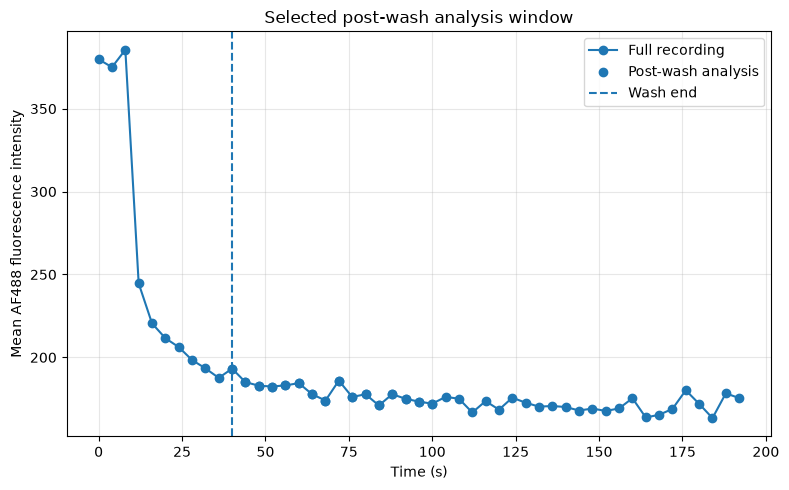

In [411]:
plt.figure(figsize=(8, 5))

plt.plot(
    time_seconds,
    af488_intensity,
    marker="o",
    label="Full recording"
)

plt.scatter(
    analysis_time,
    analysis_intensity,
    label="Post-wash analysis"
)

plt.axvline(
    wash_end_time,
    linestyle="--",
    label="Wash end"
)

plt.xlabel("Time (s)")
plt.ylabel("Mean AF488 fluorescence intensity")
plt.title("Selected post-wash analysis window")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [412]:
valid = (
    np.isfinite(analysis_intensity)
    &
    (analysis_intensity > 0)
)

fit_time = analysis_time[valid]
fit_intensity = analysis_intensity[valid]

ln_intensity = np.log(
    fit_intensity
)

In [413]:
valid = (
    np.isfinite(analysis_intensity)
    & (analysis_intensity > 0)
)

fit_time = analysis_time[valid]
fit_intensity = analysis_intensity[valid]

ln_intensity = np.log(fit_intensity)

slope, intercept = np.polyfit(
    fit_time,
    ln_intensity,
    1
)

k = -slope

predicted_ln_intensity = (
    slope * fit_time + intercept
)

print("Slope:", slope)
print("k:", k, "s^-1")

Slope: -0.0014470757071942592
k: 0.0014470757071942592 s^-1


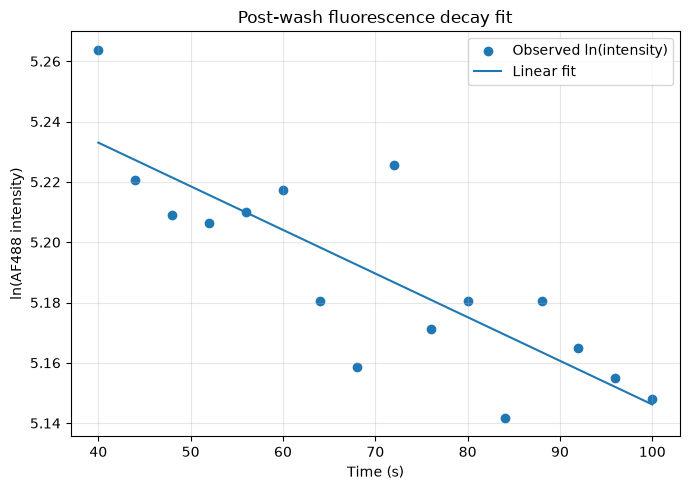

In [414]:
plt.figure(figsize=(7, 5))

plt.scatter(
    fit_time,
    ln_intensity,
    label="Observed ln(intensity)"
)

plt.plot(
    fit_time,
    predicted_ln_intensity,
    label="Linear fit"
)

plt.xlabel("Time (s)")
plt.ylabel("ln(AF488 intensity)")
plt.title("Post-wash fluorescence decay fit")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [415]:
ss_res = np.sum(
    (
        ln_intensity
        - predicted_ln_intensity
    ) ** 2
)

ss_tot = np.sum(
    (
        ln_intensity
        - np.mean(ln_intensity)
    ) ** 2
)

r_squared = (
    1 - ss_res / ss_tot
)

print("R²:", r_squared)

R²: 0.6696165901691121


In [416]:
import cv2
import numpy as np


def measure_capillary_diameters(
    frame,
    to_uint8_func,
    window_name="Measure capillary diameters"
):
    """
    Measure two inner capillary diameters interactively.

    Click:
    1. D1 start
    2. D1 end
    3. D2 start
    4. D2 end

    Returns
    -------
    points : ndarray, shape (4, 2)
        Selected points.

    d1_pixels : float
        First diameter in pixels.

    d2_pixels : float
        Second diameter in pixels.
    """

    display_frame = to_uint8_func(frame)

    display_bgr = cv2.cvtColor(
        display_frame,
        cv2.COLOR_GRAY2BGR
    )

    selected_points = []

    def mouse_callback(
        event,
        x,
        y,
        flags,
        param
    ):
        if event == cv2.EVENT_LBUTTONDOWN:

            if len(selected_points) >= 4:
                return

            selected_points.append(
                (x, y)
            )

            preview = display_bgr.copy()

            # Draw selected points
            for i, point in enumerate(
                selected_points
            ):
                cv2.circle(
                    preview,
                    point,
                    4,
                    (0, 0, 255),
                    -1
                )

                cv2.putText(
                    preview,
                    str(i + 1),
                    (
                        point[0] + 6,
                        point[1] - 6
                    ),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.5,
                    (0, 0, 255),
                    1
                )

            # Draw D1
            if len(selected_points) >= 2:
                cv2.line(
                    preview,
                    selected_points[0],
                    selected_points[1],
                    (0, 255, 0),
                    2
                )

            # Draw D2
            if len(selected_points) >= 4:
                cv2.line(
                    preview,
                    selected_points[2],
                    selected_points[3],
                    (255, 0, 0),
                    2
                )

            cv2.imshow(
                window_name,
                preview
            )

    cv2.namedWindow(
        window_name,
        cv2.WINDOW_NORMAL
    )

    cv2.imshow(
        window_name,
        display_bgr
    )

    cv2.setMouseCallback(
        window_name,
        mouse_callback
    )

    print(
        "Click 4 points:"
    )
    print(
        "1-2 = D1 (north-south inner diameter)"
    )
    print(
        "3-4 = D2 (east-west inner diameter)"
    )
    print(
        "Measure from the INNER membrane boundary."
    )
    print(
        "Press Enter after selecting 4 points."
    )

    while True:

        key = cv2.waitKey(20) & 0xFF

        if key in (13, 32):
            if len(selected_points) == 4:
                break

        if key == 27:
            selected_points = []
            break

    cv2.destroyAllWindows()
    cv2.waitKey(1)

    if len(selected_points) != 4:
        raise RuntimeError(
            "Diameter measurement cancelled."
        )

    points = np.asarray(
        selected_points,
        dtype=float
    )

    d1_pixels = np.linalg.norm(
        points[1] - points[0]
    )

    d2_pixels = np.linalg.norm(
        points[3] - points[2]
    )

    print(
        f"D1 = {d1_pixels:.2f} pixels"
    )

    print(
        f"D2 = {d2_pixels:.2f} pixels"
    )

    return (
        points,
        d1_pixels,
        d2_pixels
    )

In [417]:
measurement_frame = r18_registered[0]

points, d1_pixels, d2_pixels = (
    measure_capillary_diameters(
        frame=measurement_frame,
        to_uint8_func=to_uint8
    )
)

Click 4 points:
1-2 = D1 (north-south inner diameter)
3-4 = D2 (east-west inner diameter)
Measure from the INNER membrane boundary.
Press Enter after selecting 4 points.
D1 = 32.02 pixels
D2 = 32.20 pixels


In [418]:
x_coords = np.asarray(data.coords["X"].values, dtype=float)
y_coords = np.asarray(data.coords["Y"].values, dtype=float)

pixel_size_x = np.median(np.diff(x_coords))
pixel_size_y = np.median(np.diff(y_coords))

print("Pixel size X:", pixel_size_x, "µm/pixel")
print("Pixel size Y:", pixel_size_y, "µm/pixel")


# Convert D1 / D2 from pixels to µm
d1_um = d1_pixels * pixel_size_x
d2_um = d2_pixels * pixel_size_y

print("D1:", d1_um, "µm")
print("D2:", d2_um, "µm")

# Calculate capillary radius using lab Excel method
R_cm = (d1_um + d2_um) / 40000

print("R:", R_cm, "cm")


# Calculate Ps'alb
psalb = -(R_cm * slope) / 2

print("Slope:", slope, "s^-1")
print("Ps'alb:", psalb, "cm/s")
print(f"Ps'alb = {psalb:.3e} cm/s")

Pixel size X: 0.1972895338318068 µm/pixel
Pixel size Y: 0.1972895338318068 µm/pixel
D1: 6.3163469793513505 µm
D2: 6.353213130808362 µm
R: 0.0003167390027539928 cm
Slope: -0.0014470757071942592 s^-1
Ps'alb: 2.2917265820311928e-07 cm/s
Ps'alb = 2.292e-07 cm/s
